<a href="https://colab.research.google.com/github/abhayk001/Cab-Sharing-System/blob/main/RealTimeVoiceCloning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!git clone https://github.com/CorentinJ/Real-Time-Voice-Cloning

fatal: destination path 'Real-Time-Voice-Cloning' already exists and is not an empty directory.


In [4]:
%cd Real-Time-Voice-Cloning/

/content/Real-Time-Voice-Cloning


In [5]:
!pip install -q -r requirements.txt
!apt-get install -qq libportaudio2

In [6]:
!unzip /content/drive/MyDrive/pretrained-models.zip

Archive:  /content/drive/MyDrive/pretrained-models.zip
replace pretrained-models/encoder/encoder.pt? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [7]:
!pip install unidecode

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [9]:
from IPython.display import Audio
from IPython.utils import io
from synthesizer.inference import Synthesizer
from encoder import inference as encoder
from vocoder import inference as vocoder
from pathlib import Path
import numpy as np
import librosa
encoder_weights = Path("/content/Real-Time-Voice-Cloning/pretrained-models/encoder/encoder.pt")
vocoder_weights = Path("/content/Real-Time-Voice-Cloning/pretrained-models/vocoder/vocoder.pt")
syn_model = Path("/content/Real-Time-Voice-Cloning/pretrained-models/synthesizer/synthesizer.pt")
encoder.load_model(encoder_weights)
synthesizer = Synthesizer(syn_model)
vocoder.load_model(vocoder_weights)

Loaded encoder "encoder.pt" trained to step 1564501
Synthesizer using device: cpu
Building Wave-RNN
Trainable Parameters: 4.481M
Loading model weights at /content/Real-Time-Voice-Cloning/pretrained-models/vocoder/vocoder.pt


In [10]:
text = "This is my final year project, my project guide is Ms. Shobha"

In [2]:
def clone_voice(input_wav_file):
  original_wav, sampling_rate = librosa.load(input_wav_file)
  preprocessed_wav = encoder.preprocess_wav(original_wav, sampling_rate)
  embed = encoder.embed_utterance(preprocessed_wav)
  with io.capture_output() as captured:
    specs = synthesizer.synthesize_spectrograms([text], [embed])
  generated_wav = vocoder.infer_waveform(specs[0])
  generated_wav = np.pad(generated_wav, (0, synthesizer.sample_rate), mode="constant")
  return [generated_wav, synthesizer.sample_rate]

In [16]:
import time
begin = time.time()
[generated_wav, sample_rate] = clone_voice("/content/Real-Time-Voice-Cloning/my_voice.wav")
end = time.time()
print("Time taken for generation = " + str(end - begin))
display(Audio(generated_wav, rate=sample_rate))

{| ████████████████ 76000/76800 | Batch Size: 8 | Gen Rate: 1.9kHz | }Time taken for generation = 42.10259485244751


In [11]:
import umap.umap_ as umap
embeds = []

for i in range(0, 3):
  [generated_wav, sample_rate] = clone_voice("/content/Real-Time-Voice-Cloning/my_voice.wav")
  preprocessed_wav = encoder.preprocess_wav(generated_wav, sample_rate)
  embed = encoder.embed_utterance(preprocessed_wav)
  embeds.append(embed)

{| ████████████████ 76000/76800 | Batch Size: 8 | Gen Rate: 1.9kHz | }

In [32]:
int(np.ceil(np.sqrt(len(embeds))))

2

In [12]:
reducer = umap.UMAP(metric="cosine",  init='random')
projections = reducer.fit_transform(embeds)

/usr/local/lib/python3.8/dist-packages/umap/umap_.py:2344: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


In [13]:
projections.shape

(3, 2)

In [41]:
pip install -U matplotlib

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.4/9.4 MB 45.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.0/300.0 KB 31.0 MB/s eta 0:00:00
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.5.1
    Uninstalling matplotlib-3.5.1:
      Successfully uninstalled matplotlib-3.5.1


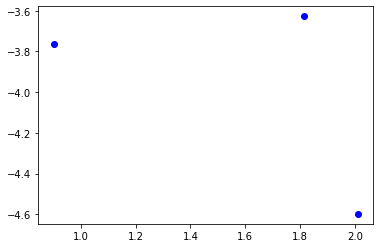

In [15]:
import matplotlib.pyplot as plt
for i in projections:
  plt.plot(i[0], i[1], 'bo')

{| ████████████████ 76000/76800 | Batch Size: 8 | Gen Rate: 1.3kHz | }

/usr/local/lib/python3.8/dist-packages/umap/umap_.py:2344: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


{| ████████████████ 85500/86400 | Batch Size: 9 | Gen Rate: 1.6kHz | }

/usr/local/lib/python3.8/dist-packages/umap/umap_.py:2344: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


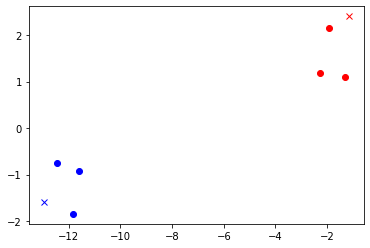

In [20]:
import umap.umap_ as umap
import matplotlib.pyplot as plt

voice_paths = ['/content/Real-Time-Voice-Cloning/my_voice.wav', '/content/Real-Time-Voice-Cloning/trump10.wav']
colors = ['blue', 'red']
voice_projections = []

for input_voice_path in voice_paths:
  original_wav, sampling_rate = librosa.load(input_voice_path)
  preprocessed_wav = encoder.preprocess_wav(original_wav, sampling_rate)
  embed = encoder.embed_utterance(preprocessed_wav)

  embeds = [embed]

  for i in range(0, 3):
    [generated_wav, sample_rate] = clone_voice(input_voice_path)
    preprocessed_wav = encoder.preprocess_wav(generated_wav, sample_rate)
    embed = encoder.embed_utterance(preprocessed_wav)
    embeds.append(embed)

  reducer = umap.UMAP(metric="cosine",  init='random')
  projections = reducer.fit_transform(embeds)

  voice_projections.append(projections)

voice_number = 0
for projections in voice_projections:
  for i in range(len(projections)):
    if(i == 0):
      plt.plot(projections[i][0], projections[i][1], color = colors[voice_number], marker = 'x')
    else:
      plt.plot(projections[i][0], projections[i][1], color = colors[voice_number], marker = 'o')
  
  voice_number += 1